# Feature Selection: Choosing What Matters

---

## The Problem of Too Many Features

Adding more features seem like something that should help. More information, better predictions, right? NOPE! or at least, not necessarily.

**Problems with high-dimensional data:**

- **Overfitting**: With many features and limited samples, models tend to be bigger (more weights) and to memorize noise
- **Computational cost**: Training time grows with dimensionality
- **The curse of dimensionality**: Data becomes sparse in high-dimensional spaces
- **Interpretability**: Hard to understand models with hundreds of inputs
- **Collection cost**: Some features are expensive to gather

**Feature selection** identifies the subset of inputs that actually contribute to prediction, discarding the rest.

### Why It Works

In practice, most datasets have:
- **Some irrelevant features**: No relationship with the target
- **Some redundant features**: Duplicating information already captured by other features
- **Noisy features**: Weak signal drowned by measurement noise

Removing these can improve generalization, speed up training, and make models more interpretable.

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)
from sklearn.metrics import accuracy_score, mean_squared_error
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## Exploring the Dataset

We'll use the breast cancer dataset. This has 30 features computed from cell nuclei images, predicting malignant vs. benign tumors.

In [2]:
# Load a real dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print("Dataset Overview:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target classes: {np.unique(y)} (0=malignant, 1=benign)")
print(f"\nFeature names:")
for i, name in enumerate(feature_names[:10]):
    print(f"  {i}: {name}")
print("  ...")

# Create DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Basic statistics
print("\nBasic Statistics:")
print(df.describe().iloc[:, :5])  # Show first 5 features

Dataset Overview:
Number of samples: 569
Number of features: 30
Target classes: [0 1] (0=malignant, 1=benign)

Feature names:
  0: mean radius
  1: mean texture
  2: mean perimeter
  3: mean area
  4: mean smoothness
  5: mean compactness
  6: mean concavity
  7: mean concave points
  8: mean symmetry
  9: mean fractal dimension
  ...

Basic Statistics:
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.

## Taxonomy of Feature Selection Methods

| Category | How It Works | Speed | Considers Interactions? |
|----------|-------------|-------|-------------------------|
| **Filter** | Ranks features using statistical tests | Fast | No |
| **Wrapper** | Evaluates feature subsets using model performance | Slow | Yes |
| **Embedded** | Selection built into model training | Medium | Yes |

Let's explore each category.

## Filter Methods

Filter methods score each feature independently using statistical measures, then keep the top-ranked ones. They're fast and model-agnostic but ignore feature interactions.

### Correlation with Target

The simplest filter: measure linear correlation between each feature and the target.

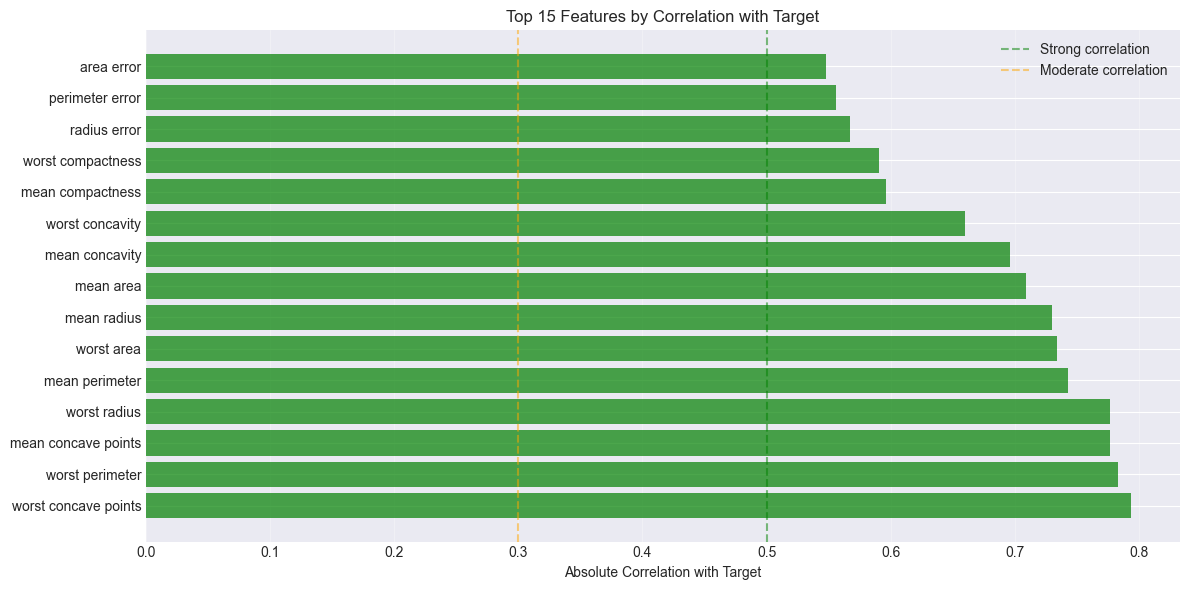


Top 10 Features by Correlation:
             Feature  Correlation
worst concave points     0.793566
     worst perimeter     0.782914
 mean concave points     0.776614
        worst radius     0.776454
      mean perimeter     0.742636
          worst area     0.733825
         mean radius     0.730029
           mean area     0.708984
      mean concavity     0.696360
     worst concavity     0.659610


In [3]:
# Calculate correlation with target
correlations = []
for i in range(X.shape[1]):
    corr, _ = pearsonr(X[:, i], y)
    correlations.append(abs(corr))

# Create DataFrame for easier viewing
corr_df = pd.DataFrame({
    'Feature': feature_names,
    'Correlation': correlations
}).sort_values('Correlation', ascending=False)

# Plot top features
plt.figure(figsize=(12, 6))
top_n = 15
colors = ['green' if c > 0.5 else 'orange' if c > 0.3 else 'red' 
          for c in corr_df['Correlation'].head(top_n)]
plt.barh(range(top_n), corr_df['Correlation'].head(top_n), color=colors, alpha=0.7)
plt.yticks(range(top_n), corr_df['Feature'].head(top_n))
plt.xlabel('Absolute Correlation with Target')
plt.title(f'Top {top_n} Features by Correlation with Target')
plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Strong correlation')
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Moderate correlation')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 Features by Correlation:")
print(corr_df.head(10).to_string(index=False))

### Feature-Feature Correlation

High correlation between features indicates **redundancy**. If two features are nearly identical, we only need one.

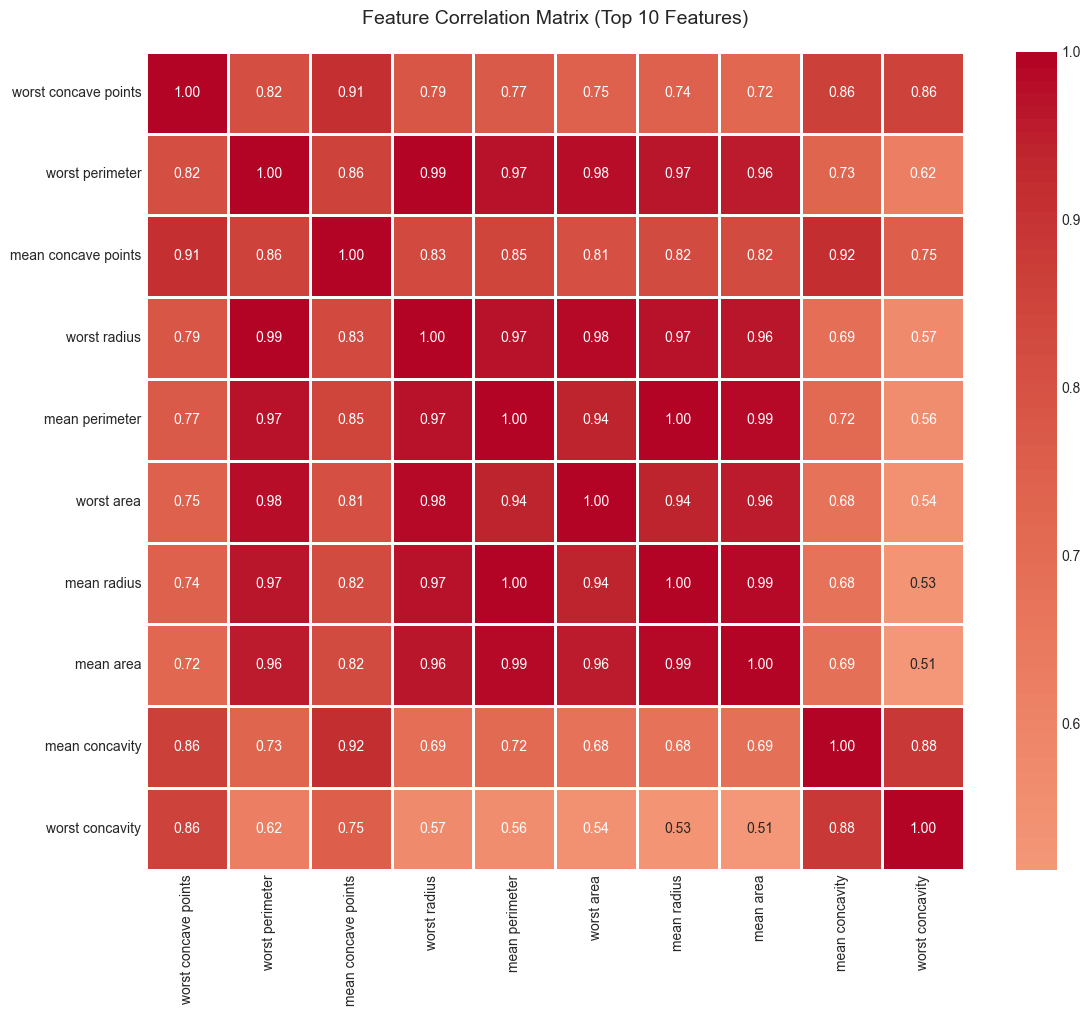


Highly Correlated Feature Pairs (>0.8):
  worst concave points           <-> worst perimeter                : 0.816
  worst concave points           <-> mean concave points            : 0.910
  worst concave points           <-> mean concavity                 : 0.861
  worst concave points           <-> worst concavity                : 0.855
  worst perimeter                <-> mean concave points            : 0.856
  worst perimeter                <-> worst radius                   : 0.994
  worst perimeter                <-> mean perimeter                 : 0.970
  worst perimeter                <-> worst area                     : 0.978
  worst perimeter                <-> mean radius                    : 0.965
  worst perimeter                <-> mean area                      : 0.959
  mean concave points            <-> worst radius                   : 0.830
  mean concave points            <-> mean perimeter                 : 0.851
  mean concave points            <-> worst area

In [5]:
# Calculate correlation matrix for top features
top_features = corr_df['Feature'].head(10).tolist()
top_indices = [list(feature_names).index(f) for f in top_features]
X_top = X[:, top_indices]

# Create correlation matrix
corr_matrix = np.corrcoef(X_top.T)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
           xticklabels=top_features,
           yticklabels=top_features,
           annot=True, fmt='.2f', 
           cmap='coolwarm', center=0,
           square=True,
           linewidths=1)
plt.title('Feature Correlation Matrix (Top 10 Features)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\nHighly Correlated Feature Pairs (>0.8):")
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        if abs(corr_matrix[i, j]) > 0.8:
            print(f"  {top_features[i]:<30} <-> {top_features[j]:<30} : {corr_matrix[i, j]:.3f}")

### ANOVA F-test

For classification, the F-test measures how well a feature separates classes. It compares:
- **Between-class variance**: How different are the class means?
- **Within-class variance**: How spread out is each class?

High F-score = good class separation.

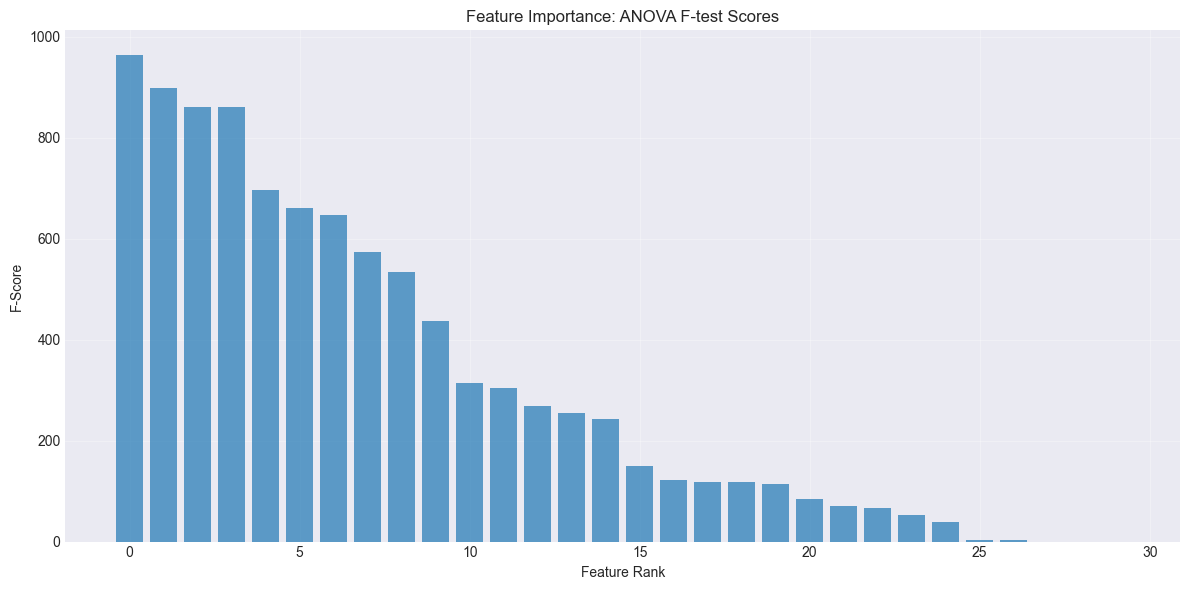


Top 10 Features by F-Score:
             Feature    F-Score
worst concave points 964.385393
     worst perimeter 897.944219
 mean concave points 861.676020
        worst radius 860.781707
      mean perimeter 697.235272
          worst area 661.600206
         mean radius 646.981021
           mean area 573.060747
      mean concavity 533.793126
     worst concavity 436.691939


In [6]:
# Calculate F-scores
f_selector = SelectKBest(f_classif, k='all')
f_selector.fit(X, y)

# Get scores
f_scores = f_selector.scores_
f_df = pd.DataFrame({
    'Feature': feature_names,
    'F-Score': f_scores
}).sort_values('F-Score', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(f_scores)), sorted(f_scores, reverse=True), alpha=0.7)
plt.xlabel('Feature Rank')
plt.ylabel('F-Score')
plt.title('Feature Importance: ANOVA F-test Scores')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Features by F-Score:")
print(f_df.head(10).to_string(index=False))

### Mutual Information

Unlike correlation (linear only), **mutual information** captures any statistical dependency, linear or nonlinear.

$$I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$$

- MI = 0 → features are independent (no information shared)
- Higher MI → stronger dependency

**Caveats**: MI is harder to estimate than correlation and can be noisy with limited data.

In [12]:
# Calculate mutual information
mi_selector = SelectKBest(mutual_info_classif, k='all')
mi_selector.fit(X, y)

mi_scores = mi_selector.scores_
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI-Score': mi_scores
}).sort_values('MI-Score', ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))


Top 10 Features by Mutual Information:
             Feature  MI-Score
     worst perimeter  0.473125
          worst area  0.464456
        worst radius  0.451787
 mean concave points  0.441545
worst concave points  0.439481
      mean perimeter  0.405132
      mean concavity  0.372862
         mean radius  0.367819
           mean area  0.357680
          area error  0.340417


## Wrapper Methods

Wrapper methods treat feature selection as a search problem: find the subset that maximizes model performance. They're more expensive but account for feature interactions.

### Recursive Feature Elimination (RFE)

RFE works backwards:
1. Train model on all features
2. Rank features by importance (coefficients for linear models, impurity reduction for trees)
3. Remove the least important feature
4. Repeat until desired number of features remains

This captures interactions because importance is computed with other features present.

In [14]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply RFE with logistic regression
estimator = LogisticRegression(max_iter=10000, random_state=42)
n_features_to_select = 10

rfe = RFE(estimator, n_features_to_select=n_features_to_select, step=1)
rfe.fit(X_train, y_train)

# Get rankings
rfe_df = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('Ranking')

print("\nRFE Results:")
print(rfe_df.head(15).to_string(index=False))

# Evaluate performance
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

estimator.fit(X_train_rfe, y_train)
rfe_accuracy = estimator.score(X_test_rfe, y_test)
print(f"\nAccuracy with {n_features_to_select} selected features: {rfe_accuracy:.4f}")


RFE Results:
             Feature  Ranking  Selected
         mean radius        1      True
    mean compactness        1      True
      mean concavity        1      True
       texture error        1      True
      worst symmetry        1      True
   worst compactness        1      True
     worst concavity        1      True
        worst radius        1      True
    worst smoothness        1      True
worst concave points        1      True
 mean concave points        2     False
     perimeter error        3     False
       worst texture        4     False
       mean symmetry        5     False
        mean texture        6     False

Accuracy with 10 selected features: 0.9737


### Finding the Optimal Number of Features

How many features should we keep? Test different values and use cross-validation to find the sweet spot.

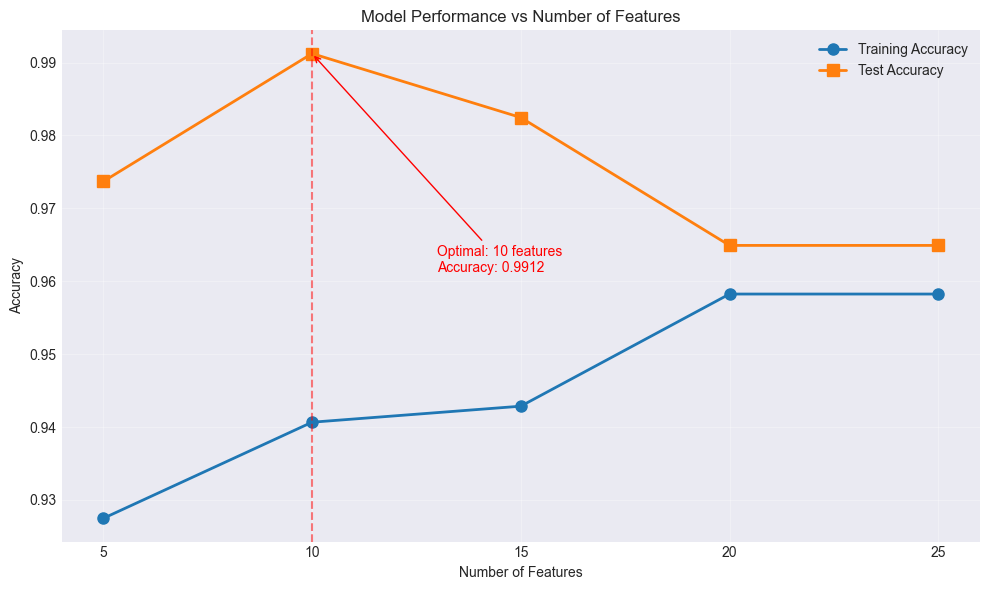


Optimal number of features: 10
Test accuracy: 0.9912


In [16]:
# Test different numbers of features
feature_counts = range(5, 30, 5)
train_scores = []
test_scores = []

for n_features in feature_counts:
    # Use SelectKBest for speed
    selector = SelectKBest(f_classif, k=n_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Train and evaluate
    model = LogisticRegression(max_iter=10000, random_state=42)
    model.fit(X_train_selected, y_train)
    
    train_scores.append(model.score(X_train_selected, y_train))
    test_scores.append(model.score(X_test_selected, y_test))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(feature_counts, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(feature_counts, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Model Performance vs Number of Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(feature_counts)

# Mark optimal point
optimal_idx = np.argmax(test_scores)
optimal_features = list(feature_counts)[optimal_idx]
optimal_score = test_scores[optimal_idx]
plt.axvline(x=optimal_features, color='red', linestyle='--', alpha=0.5)
plt.annotate(f'Optimal: {optimal_features} features\nAccuracy: {optimal_score:.4f}',
            xy=(optimal_features, optimal_score),
            xytext=(optimal_features + 3, optimal_score - 0.03),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal number of features: {optimal_features}")
print(f"Test accuracy: {optimal_score:.4f}")

## Embedded Methods

Embedded methods perform feature selection as part of model training, the algorithm inherently assigns zero or near-zero weight to irrelevant features.

### L1 Regularization (Lasso)

L1 regularization adds $\lambda \sum |w_i|$ to the loss function. This penalty has a special property: it drives coefficients to **exactly zero**, effectively removing features from the model.

/Users/davide/.venvs/ml-notes-dave/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/davide/.venvs/ml-notes-dave/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/davide/.venvs/ml-notes-dave/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


L1 Regularization selected 8 out of 30 features


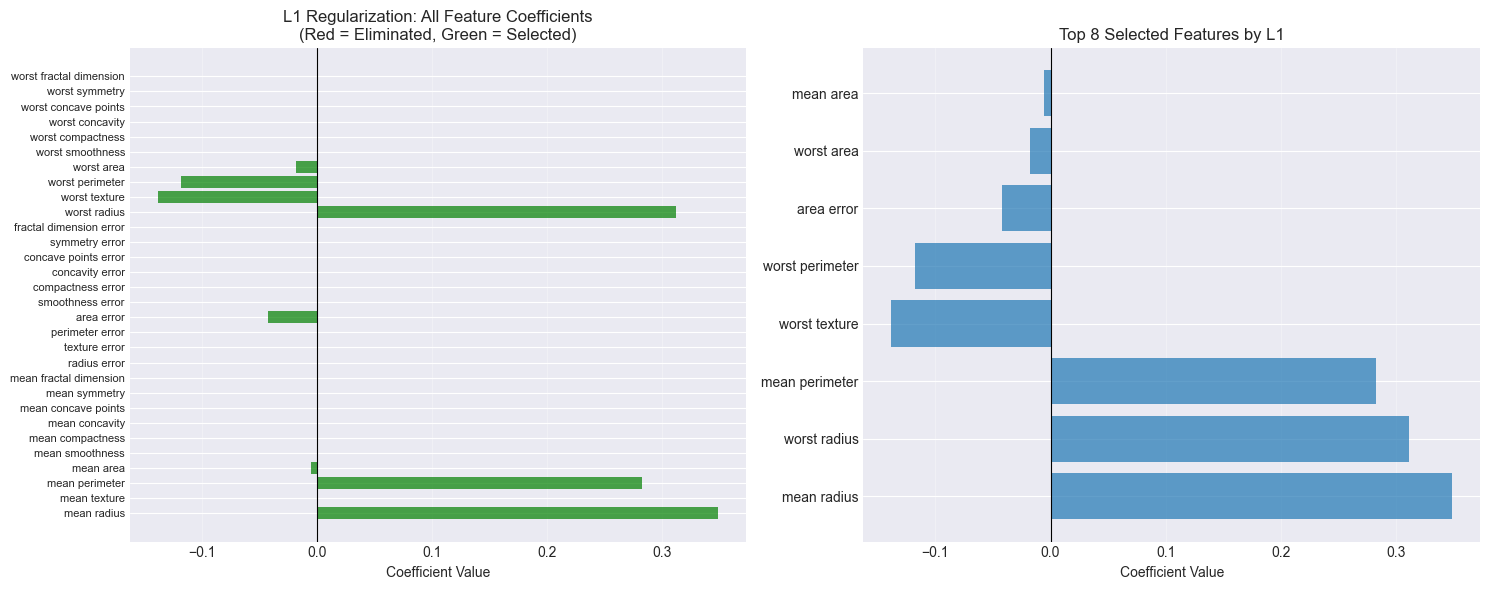


Test accuracy with L1-selected features: 0.9561


In [17]:
# Train L1-regularized logistic regression
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
l1_model.fit(X_train, y_train)

# Get coefficients
coefficients = l1_model.coef_[0]
l1_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Count non-zero features
n_selected = np.sum(coefficients != 0)
print(f"L1 Regularization selected {n_selected} out of {len(feature_names)} features")

# Plot coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: All coefficients
colors = ['red' if c == 0 else 'green' for c in coefficients]
ax1.barh(range(len(coefficients)), coefficients, color=colors, alpha=0.7)
ax1.set_yticks(range(len(feature_names)))
ax1.set_yticklabels(feature_names, fontsize=8)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('L1 Regularization: All Feature Coefficients\n(Red = Eliminated, Green = Selected)')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Non-zero coefficients only
non_zero_df = l1_df[l1_df['Coefficient'] != 0].head(15)
ax2.barh(range(len(non_zero_df)), non_zero_df['Coefficient'], alpha=0.7)
ax2.set_yticks(range(len(non_zero_df)))
ax2.set_yticklabels(non_zero_df['Feature'])
ax2.set_xlabel('Coefficient Value')
ax2.set_title(f'Top {len(non_zero_df)} Selected Features by L1')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Evaluate
l1_accuracy = l1_model.score(X_test, y_test)
print(f"\nTest accuracy with L1-selected features: {l1_accuracy:.4f}")

### Tree-Based Feature Importance

Decision trees and random forests measure feature importance by how much each feature contributes to reducing impurity (Gini or entropy) across all splits.

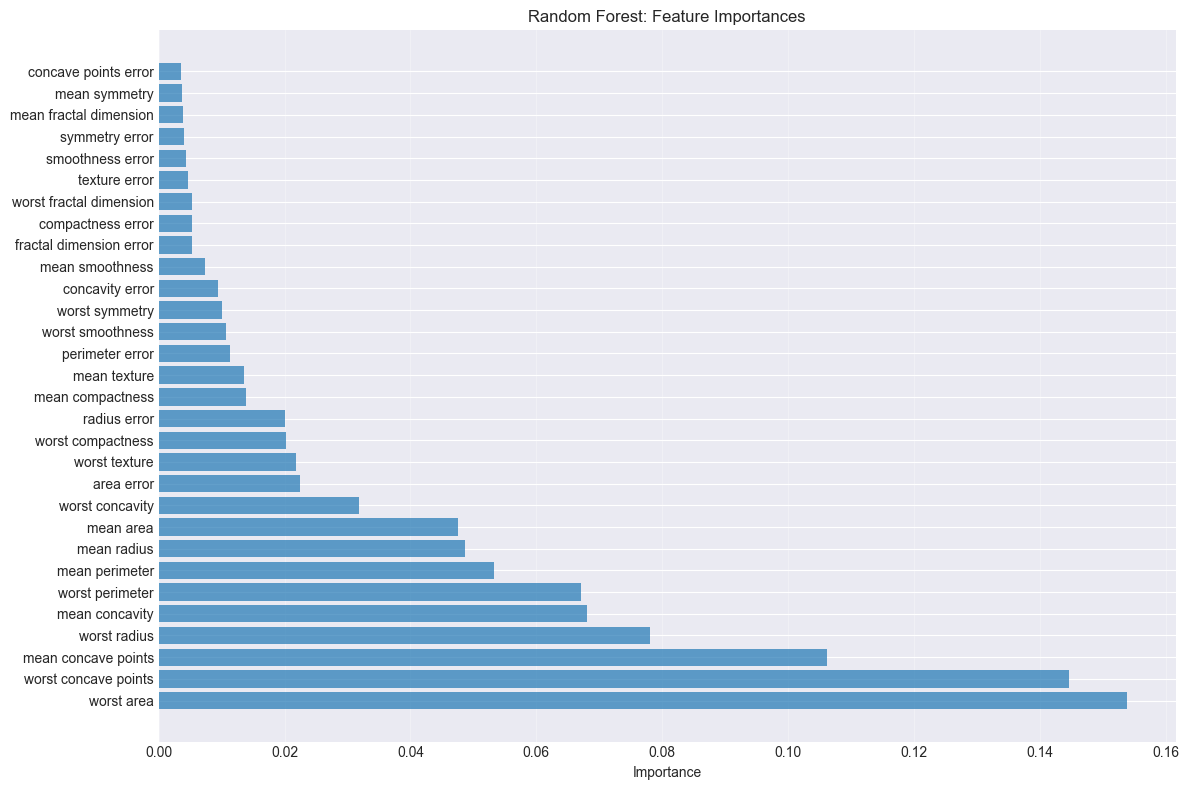


Top 10 Features by Random Forest Importance:
             Feature  Importance
          worst area    0.153892
worst concave points    0.144663
 mean concave points    0.106210
        worst radius    0.077987
      mean concavity    0.068001
     worst perimeter    0.067115
      mean perimeter    0.053270
         mean radius    0.048703
           mean area    0.047555
     worst concavity    0.031802

Test accuracy: 0.9649


In [18]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
rf_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(len(rf_df)), rf_df['Importance'], alpha=0.7)
plt.yticks(range(len(rf_df)), rf_df['Feature'])
plt.xlabel('Importance')
plt.title('Random Forest: Feature Importances')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 Features by Random Forest Importance:")
print(rf_df.head(10).to_string(index=False))

# Evaluate
rf_accuracy = rf_model.score(X_test, y_test)
print(f"\nTest accuracy: {rf_accuracy:.4f}")

### SelectFromModel: Automatic Thresholding

Use the model's built-in importance scores to automatically select features above a threshold.

In [20]:
# Use median importance as threshold
selector = SelectFromModel(rf_model, threshold='median')
selector.fit(X_train, y_train)

# Transform data
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get selected features
selected_features = feature_names[selector.get_support()]
print(f"SelectFromModel chose {len(selected_features)} features:")
for feat in selected_features:
    print(f"  - {feat}")

# Train new model on selected features
new_model = RandomForestClassifier(n_estimators=100, random_state=42)
new_model.fit(X_train_selected, y_train)
selected_accuracy = new_model.score(X_test_selected, y_test)

print(f"\nAccuracy with selected features: {selected_accuracy:.4f}")
print(f"Accuracy with all features: {rf_accuracy:.4f}")
print(f"Feature reduction: {X.shape[1]} -> {X_train_selected.shape[1]} ({X_train_selected.shape[1]/X.shape[1]*100:.1f}%)")

SelectFromModel chose 15 features:
  - mean radius
  - mean perimeter
  - mean area
  - mean compactness
  - mean concavity
  - mean concave points
  - radius error
  - area error
  - worst radius
  - worst texture
  - worst perimeter
  - worst area
  - worst compactness
  - worst concavity
  - worst concave points

Accuracy with selected features: 0.9561
Accuracy with all features: 0.9649
Feature reduction: 30 -> 15 (50.0%)


## Comparing All Methods


Feature Selection Methods Comparison
                Method  Features  Train Acc  Test Acc  Overfit Gap
       Top 10 (F-test)        10   0.940659  0.991228    -0.050569
           Top 10 (MI)        10   0.940659  0.991228    -0.050569
              RFE (10)        10   0.949451  0.973684    -0.024234
     L1 Regularization         8   0.949451  0.964912    -0.015462
Random Forest (median)        15   0.953846  0.964912    -0.011066
          All Features        30   0.962637  0.956140     0.006497


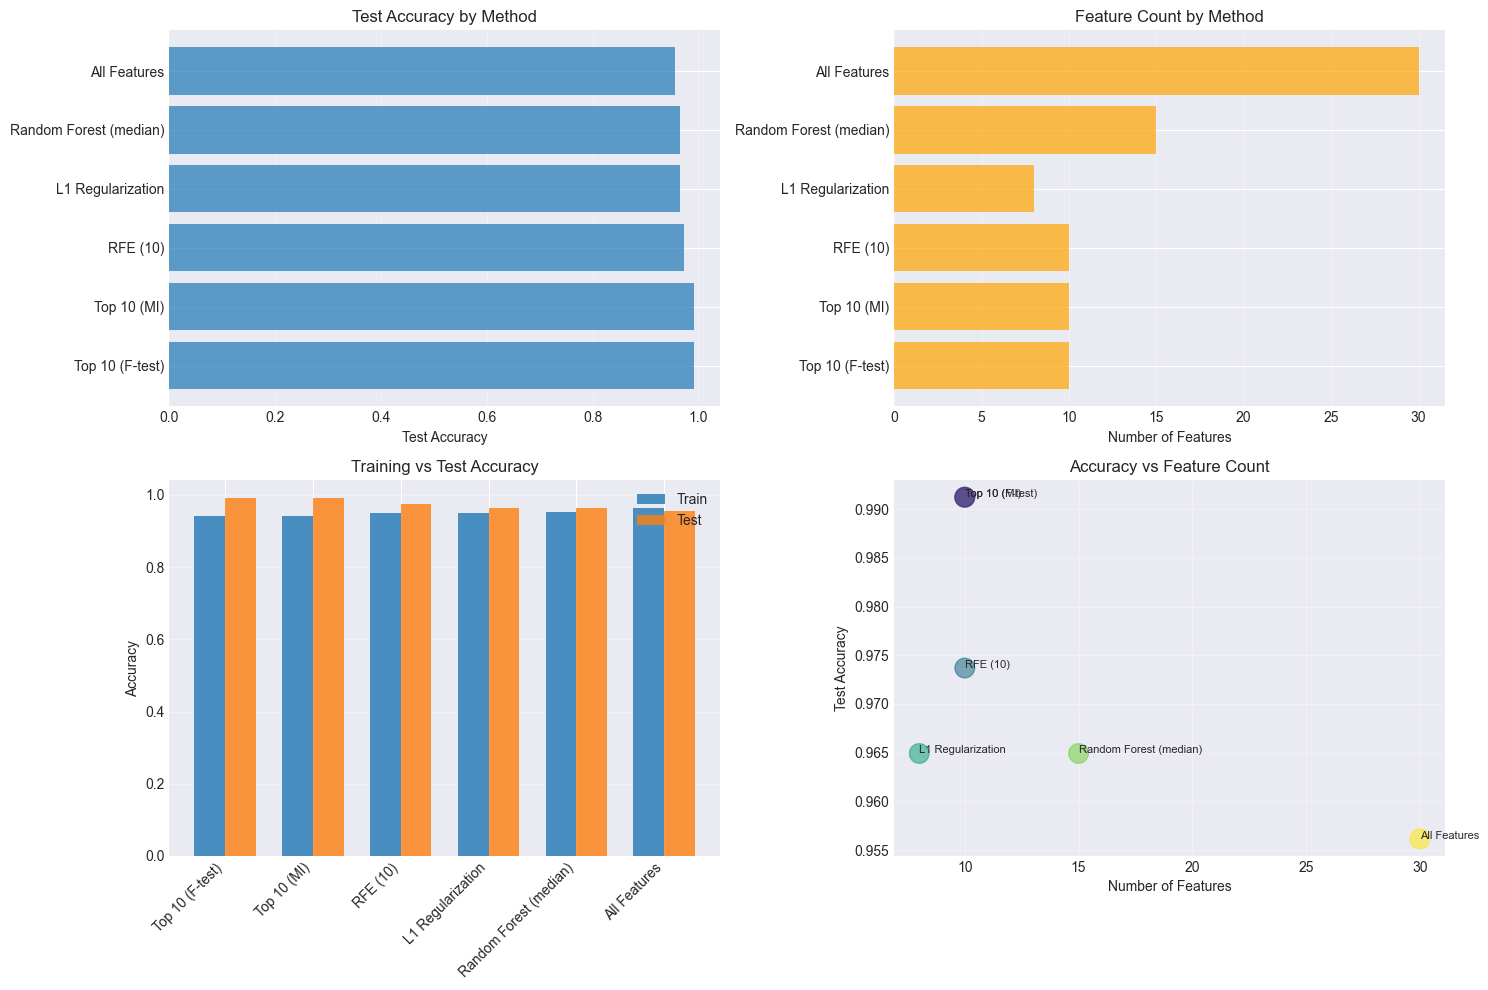

In [21]:
# Collect all methods
methods = {
    'All Features': (X_train, X_test),
    'Top 10 (F-test)': None,
    'Top 10 (MI)': None,
    'RFE (10)': (X_train_rfe, X_test_rfe),
    'L1 Regularization': None,
    'Random Forest (median)': (X_train_selected, X_test_selected)
}

# Add missing methods
# F-test top 10
f_selector_10 = SelectKBest(f_classif, k=10)
X_train_f = f_selector_10.fit_transform(X_train, y_train)
X_test_f = f_selector_10.transform(X_test)
methods['Top 10 (F-test)'] = (X_train_f, X_test_f)

# MI top 10
mi_selector_10 = SelectKBest(mutual_info_classif, k=10)
X_train_mi = mi_selector_10.fit_transform(X_train, y_train)
X_test_mi = mi_selector_10.transform(X_test)
methods['Top 10 (MI)'] = (X_train_mi, X_test_mi)

# L1 selection
l1_selector = SelectFromModel(l1_model, prefit=True)
X_train_l1 = l1_selector.transform(X_train)
X_test_l1 = l1_selector.transform(X_test)
methods['L1 Regularization'] = (X_train_l1, X_test_l1)

# Evaluate all methods
results = []
for method_name, (X_tr, X_te) in methods.items():
    model = LogisticRegression(max_iter=10000, random_state=42)
    model.fit(X_tr, y_train)
    
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    n_features = X_tr.shape[1]
    
    results.append({
        'Method': method_name,
        'Features': n_features,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfit Gap': train_acc - test_acc
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Acc', ascending=False)

print("\n" + "="*80)
print("Feature Selection Methods Comparison")
print("="*80)
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Test Accuracy
axes[0, 0].barh(range(len(results_df)), results_df['Test Acc'], alpha=0.7)
axes[0, 0].set_yticks(range(len(results_df)))
axes[0, 0].set_yticklabels(results_df['Method'])
axes[0, 0].set_xlabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy by Method')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Number of Features
axes[0, 1].barh(range(len(results_df)), results_df['Features'], 
               color='orange', alpha=0.7)
axes[0, 1].set_yticks(range(len(results_df)))
axes[0, 1].set_yticklabels(results_df['Method'])
axes[0, 1].set_xlabel('Number of Features')
axes[0, 1].set_title('Feature Count by Method')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Train vs Test
x = np.arange(len(results_df))
width = 0.35
axes[1, 0].bar(x - width/2, results_df['Train Acc'], width, label='Train', alpha=0.8)
axes[1, 0].bar(x + width/2, results_df['Test Acc'], width, label='Test', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(results_df['Method'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Training vs Test Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Accuracy vs Features
axes[1, 1].scatter(results_df['Features'], results_df['Test Acc'], 
                  s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for idx, row in results_df.iterrows():
    axes[1, 1].annotate(row['Method'], 
                       (row['Features'], row['Test Acc']),
                       fontsize=8, ha='left')
axes[1, 1].set_xlabel('Number of Features')
axes[1, 1].set_ylabel('Test Accuracy')
axes[1, 1].set_title('Accuracy vs Feature Count')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

### Method Selection Guide

| Method | Speed | Best For |
|--------|-------|----------|
| **Correlation / F-test** | Fast | Quick baseline, linear relationships |
| **Mutual Information** | Medium | Nonlinear relationships, exploratory analysis |
| **RFE** | Slow | When feature interactions matter, final selection |
| **L1 Regularization** | Fast | Built into training, sparse models |
| **Tree Importance** | Medium | Nonlinear, complex interactions |

### Practical Workflow

1. **Start with domain knowledge** remove obviously irrelevant features
2. **Check for redundancy** correlation matrix to find duplicates
3. **Apply quick filters** variance threshold, F-test
4. **Try multiple methods** compare filter, wrapper, embedded
5. **Validate with cross-validation** ensure selection generalizes
6. **Consider practical constraints** collection cost, interpretability

### Common Mistakes

| Mistake | Why It's Bad | Fix |
|---------|-------------|-----|
| Selecting on full dataset | Data leakage | Fit selectors on training data only |
| Ignoring domain knowledge | Statistics aren't everything | Consult experts |
| Maximizing feature count | More features ≠ better | Use validation to find optimal count |
| Single method | Different methods capture different signals | Try multiple approaches |